In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import cv2

from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

import tensorflow as tf
from tensorflow.keras import layers, models

2026-06-07 15:08:40.197701: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780844920.419839      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780844920.482347      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780844921.000802      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780844921.000844      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780844921.000847      23 computation_placer.cc:177] computation placer alr

# DATASET

In [2]:
# -----------------------------
# CLEAN DATASET
# -----------------------------

kodak_clean_dir = Path(
    "/kaggle/input/datasets/sherylmehta/kodak-dataset"
)

bsd500_clean_dir = Path(
    "/kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images"
)

div2k_clean_base_dir = Path(
    "/kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images"
)


# -----------------------------
# BSD500 CLEAN SPLIT
# -----------------------------

bsd500_train_clean_dir = bsd500_clean_dir / "train"
bsd500_val_clean_dir   = bsd500_clean_dir / "val"
bsd500_test_clean_dir  = bsd500_clean_dir / "test"


# -----------------------------
# DIV2K CLEAN SPLIT
# -----------------------------

div2k_train_clean_dir = div2k_clean_base_dir / "DIV2K_train_HR" / "DIV2K_train_HR"
div2k_valid_clean_dir = div2k_clean_base_dir / "DIV2K_valid_HR" / "DIV2K_valid_HR"

In [3]:
# -----------------------------
# OUTPUT NOISY DATASET FOR N2N
# RANDOM-VALUED IMPULSE NOISE
# -----------------------------

n2n_impulse_base_dir = Path(
    "/kaggle/working/n2n_random_impulse_p010_datasets"
)

# Kodak
kodak_noisy1_dir = n2n_impulse_base_dir / "kodak" / "noisy1"
kodak_noisy2_dir = n2n_impulse_base_dir / "kodak" / "noisy2"

# BSD500
bsd500_noisy1_dir = n2n_impulse_base_dir / "bsd500" / "noisy1"
bsd500_noisy2_dir = n2n_impulse_base_dir / "bsd500" / "noisy2"

# DIV2K
div2k_noisy1_base_dir = n2n_impulse_base_dir / "div2k" / "noisy1"
div2k_noisy2_base_dir = n2n_impulse_base_dir / "div2k" / "noisy2"


# -----------------------------
# OUTPUT MODEL / DENOISED
# -----------------------------

n2n_output_dir = Path(
    "/kaggle/working/n2n_random_impulse_p010_outputs"
)

n2n_output_dir.mkdir(parents=True, exist_ok=True)

In [4]:
def get_image_paths(input_dir):
    """
    Restituisce tutti i path delle immagini contenute in input_dir,
    includendo eventuali sottocartelle.
    """

    input_dir = Path(input_dir)

    image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

    image_paths = [
        p for p in input_dir.rglob("*")
        if p.suffix.lower() in image_extensions
    ]

    return sorted(image_paths)

In [5]:
def add_random_valued_impulse_noise(
    image,
    p=0.10,
    seed=None
):
    """
    Aggiunge random-valued impulse noise.

    Una percentuale p dei pixel viene selezionata casualmente.
    Ogni pixel corrotto viene sostituito con un valore casuale:

        grayscale: valore casuale in [0, 255]
        RGB/BGR: colore casuale indipendente sui tre canali

    Parameters
    ----------
    image : np.ndarray
        Immagine uint8 in [0, 255].
    p : float
        Probabilità di corruzione del pixel.
    seed : int oppure None
        Seed per la riproducibilità.
    """

    rng = np.random.default_rng(seed)

    noisy_image = image.copy()

    height, width = image.shape[:2]

    mask = rng.random((height, width)) < p

    if image.ndim == 3:
        random_values = rng.integers(
            low=0,
            high=256,
            size=image.shape,
            dtype=np.uint8
        )

        noisy_image[mask] = random_values[mask]

    else:
        random_values = rng.integers(
            low=0,
            high=256,
            size=(height, width),
            dtype=np.uint8
        )

        noisy_image[mask] = random_values[mask]

    return noisy_image

In [6]:
def create_random_impulse_n2n_pair_dataset(
    input_dir,
    output_dir_noisy1,
    output_dir_noisy2,
    p=0.10,
    seed1=42,
    seed2=123
):
    """
    Crea due versioni rumorose indipendenti dello stesso dataset clean
    utilizzando random-valued impulse noise.

    Noise2Noise:
        input  = noisy1
        target = noisy2

    Le due immagini condividono lo stesso contenuto pulito e lo stesso
    valore di p, ma usano maschere e valori casuali differenti.
    """

    input_dir = Path(input_dir)
    output_dir_noisy1 = Path(output_dir_noisy1)
    output_dir_noisy2 = Path(output_dir_noisy2)

    output_dir_noisy1.mkdir(parents=True, exist_ok=True)
    output_dir_noisy2.mkdir(parents=True, exist_ok=True)

    image_paths = get_image_paths(input_dir)

    print("Cartella input clean:", input_dir)
    print("Output noisy1:", output_dir_noisy1)
    print("Output noisy2:", output_dir_noisy2)
    print("Probabilità di corruzione p:", p)
    print("Immagini trovate:", len(image_paths))

    psnr_values_noisy1 = []
    psnr_values_noisy2 = []
    ssim_values_noisy1 = []
    ssim_values_noisy2 = []
    processed_images = []

    for idx, img_path in enumerate(tqdm(image_paths)):

        image = cv2.imread(str(img_path), cv2.IMREAD_COLOR)

        if image is None:
            print("Immagine non letta:", img_path)
            continue

        noisy1 = add_random_valued_impulse_noise(
            image=image,
            p=p,
            seed=seed1 + idx
        )

        noisy2 = add_random_valued_impulse_noise(
            image=image,
            p=p,
            seed=seed2 + idx
        )

        relative_path = img_path.relative_to(input_dir)

        save_path_noisy1 = output_dir_noisy1 / relative_path
        save_path_noisy2 = output_dir_noisy2 / relative_path

        save_path_noisy1.parent.mkdir(parents=True, exist_ok=True)
        save_path_noisy2.parent.mkdir(parents=True, exist_ok=True)

        success1 = cv2.imwrite(str(save_path_noisy1), noisy1)
        success2 = cv2.imwrite(str(save_path_noisy2), noisy2)

        if not success1 or not success2:
            print("Errore nel salvataggio:", relative_path)
            continue

        psnr_values_noisy1.append(
            psnr(image, noisy1, data_range=255)
        )

        psnr_values_noisy2.append(
            psnr(image, noisy2, data_range=255)
        )

        ssim_values_noisy1.append(
            ssim(
                image,
                noisy1,
                channel_axis=2,
                data_range=255
            )
        )

        ssim_values_noisy2.append(
            ssim(
                image,
                noisy2,
                channel_axis=2,
                data_range=255
            )
        )

        processed_images.append(img_path.name)

    print("Immagini processate:", len(processed_images))

    if psnr_values_noisy1:
        print(
            "PSNR medio clean/noisy1:",
            np.mean(psnr_values_noisy1)
        )
        print(
            "PSNR medio clean/noisy2:",
            np.mean(psnr_values_noisy2)
        )
        print(
            "SSIM medio clean/noisy1:",
            np.mean(ssim_values_noisy1)
        )
        print(
            "SSIM medio clean/noisy2:",
            np.mean(ssim_values_noisy2)
        )

    return {
        "image_paths": image_paths,
        "processed_images": processed_images,
        "psnr_noisy1": psnr_values_noisy1,
        "psnr_noisy2": psnr_values_noisy2,
        "ssim_noisy1": ssim_values_noisy1,
        "ssim_noisy2": ssim_values_noisy2,
    }

In [7]:
kodak_generation_results = create_random_impulse_n2n_pair_dataset(
    input_dir=kodak_clean_dir,
    output_dir_noisy1=kodak_noisy1_dir,
    output_dir_noisy2=kodak_noisy2_dir,
    p=0.10,
    seed1=42,
    seed2=123
)

Cartella input clean: /kaggle/input/datasets/sherylmehta/kodak-dataset
Output noisy1: /kaggle/working/n2n_random_impulse_p010_datasets/kodak/noisy1
Output noisy2: /kaggle/working/n2n_random_impulse_p010_datasets/kodak/noisy2
Probabilità di corruzione p: 0.1
Immagini trovate: 24


100%|██████████| 24/24 [00:13<00:00,  1.80it/s]

Immagini processate: 24
PSNR medio clean/noisy1: 18.56285938459608
PSNR medio clean/noisy2: 18.564154527248366
SSIM medio clean/noisy1: 0.3415900765868345
SSIM medio clean/noisy2: 0.3414183790508137


In [8]:
bsd500_generation_results = create_random_impulse_n2n_pair_dataset(
    input_dir=bsd500_clean_dir,
    output_dir_noisy1=bsd500_noisy1_dir,
    output_dir_noisy2=bsd500_noisy2_dir,
    p=0.10,
    seed1=42,
    seed2=123
)

Cartella input clean: /kaggle/input/datasets/balraj98/berkeley-segmentation-dataset-500-bsds500/images
Output noisy1: /kaggle/working/n2n_random_impulse_p010_datasets/bsd500/noisy1
Output noisy2: /kaggle/working/n2n_random_impulse_p010_datasets/bsd500/noisy2
Probabilità di corruzione p: 0.1
Immagini trovate: 500


100%|██████████| 500/500 [01:22<00:00,  6.07it/s]

Immagini processate: 500
PSNR medio clean/noisy1: 18.245844465709002
PSNR medio clean/noisy2: 18.246330284137468
SSIM medio clean/noisy1: 0.3813511116792452
SSIM medio clean/noisy2: 0.38139264091381253


In [9]:
div2k_train_generation_results = create_random_impulse_n2n_pair_dataset(
    input_dir=div2k_train_clean_dir,
    output_dir_noisy1=div2k_noisy1_base_dir / "DIV2K_train_HR",
    output_dir_noisy2=div2k_noisy2_base_dir / "DIV2K_train_HR",
    p=0.10,
    seed1=42,
    seed2=123
)

Cartella input clean: /kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_train_HR/DIV2K_train_HR
Output noisy1: /kaggle/working/n2n_random_impulse_p010_datasets/div2k/noisy1/DIV2K_train_HR
Output noisy2: /kaggle/working/n2n_random_impulse_p010_datasets/div2k/noisy2/DIV2K_train_HR
Probabilità di corruzione p: 0.1
Immagini trovate: 800


100%|██████████| 800/800 [40:17<00:00,  3.02s/it]

Immagini processate: 800
PSNR medio clean/noisy1: 17.78742583061475
PSNR medio clean/noisy2: 17.787637828275827
SSIM medio clean/noisy1: 0.316487605886989
SSIM medio clean/noisy2: 0.31649491792351386


In [10]:
div2k_valid_generation_results = create_random_impulse_n2n_pair_dataset(
    input_dir=div2k_valid_clean_dir,
    output_dir_noisy1=div2k_noisy1_base_dir / "DIV2K_valid_HR",
    output_dir_noisy2=div2k_noisy2_base_dir / "DIV2K_valid_HR",
    p=0.10,
    seed1=2024,
    seed2=3024
)

Cartella input clean: /kaggle/input/datasets/soumikrakshit/div2k-high-resolution-images/DIV2K_valid_HR/DIV2K_valid_HR
Output noisy1: /kaggle/working/n2n_random_impulse_p010_datasets/div2k/noisy1/DIV2K_valid_HR
Output noisy2: /kaggle/working/n2n_random_impulse_p010_datasets/div2k/noisy2/DIV2K_valid_HR
Probabilità di corruzione p: 0.1
Immagini trovate: 100


100%|██████████| 100/100 [05:12<00:00,  3.12s/it]

Immagini processate: 100
PSNR medio clean/noisy1: 17.76351587371744
PSNR medio clean/noisy2: 17.76076571444344
SSIM medio clean/noisy1: 0.31902711937988726
SSIM medio clean/noisy2: 0.31893682214133157


In [11]:
print("Kodak noisy1:", len(get_image_paths(kodak_noisy1_dir)))
print("Kodak noisy2:", len(get_image_paths(kodak_noisy2_dir)))

print("BSD500 noisy1:", len(get_image_paths(bsd500_noisy1_dir)))
print("BSD500 noisy2:", len(get_image_paths(bsd500_noisy2_dir)))

print("DIV2K train noisy1:", len(get_image_paths(div2k_noisy1_base_dir / "DIV2K_train_HR")))
print("DIV2K train noisy2:", len(get_image_paths(div2k_noisy2_base_dir / "DIV2K_train_HR")))

print("DIV2K valid noisy1:", len(get_image_paths(div2k_noisy1_base_dir / "DIV2K_valid_HR")))
print("DIV2K valid noisy2:", len(get_image_paths(div2k_noisy2_base_dir / "DIV2K_valid_HR")))

Kodak noisy1: 24
Kodak noisy2: 24
BSD500 noisy1: 500
BSD500 noisy2: 500
DIV2K train noisy1: 800
DIV2K train noisy2: 800
DIV2K valid noisy1: 100
DIV2K valid noisy2: 100


In [12]:
def show_n2n_noisy_pair(clean_dir, noisy1_dir, noisy2_dir, index=0):
    """
    Visualizza una coppia Noise2Noise:
    - immagine clean originale
    - prima versione rumorosa noisy1
    - seconda versione rumorosa noisy2
    - differenza assoluta tra noisy1 e noisy2

    Serve per verificare graficamente che noisy1 e noisy2:
    - provengano dalla stessa immagine clean;
    - abbiano lo stesso tipo/livello di rumore;
    - siano due realizzazioni casuali diverse.
    """

    clean_dir = Path(clean_dir)
    noisy1_dir = Path(noisy1_dir)
    noisy2_dir = Path(noisy2_dir)

    noisy1_paths = get_image_paths(noisy1_dir)

    if len(noisy1_paths) == 0:
        print("Nessuna immagine trovata in noisy1_dir.")
        return

    if index >= len(noisy1_paths):
        print("Indice fuori range.")
        print("Numero immagini disponibili:", len(noisy1_paths))
        return

    noisy1_path = noisy1_paths[index]
    relative_path = noisy1_path.relative_to(noisy1_dir)

    noisy2_path = noisy2_dir / relative_path
    clean_path = clean_dir / relative_path

    print("Clean:", clean_path)
    print("Noisy1:", noisy1_path)
    print("Noisy2:", noisy2_path)

    if not clean_path.exists():
        print("Clean non trovata:", clean_path)
        return

    if not noisy2_path.exists():
        print("Noisy2 non trovata:", noisy2_path)
        return

    clean_img = Image.open(clean_path).convert("RGB")
    noisy1_img = Image.open(noisy1_path).convert("RGB")
    noisy2_img = Image.open(noisy2_path).convert("RGB")

    # Uniformo le dimensioni per sicurezza
    noisy1_img = noisy1_img.resize(clean_img.size)
    noisy2_img = noisy2_img.resize(clean_img.size)

    clean_np = np.array(clean_img).astype(np.float32) / 255.0
    noisy1_np = np.array(noisy1_img).astype(np.float32) / 255.0
    noisy2_np = np.array(noisy2_img).astype(np.float32) / 255.0

    diff_np = np.abs(noisy1_np - noisy2_np)

    psnr_noisy1 = psnr(clean_np, noisy1_np, data_range=1.0)
    psnr_noisy2 = psnr(clean_np, noisy2_np, data_range=1.0)

    ssim_noisy1 = ssim(clean_np, noisy1_np, channel_axis=2, data_range=1.0)
    ssim_noisy2 = ssim(clean_np, noisy2_np, channel_axis=2, data_range=1.0)

    plt.figure(figsize=(22, 6))

    plt.subplot(1, 4, 1)
    plt.imshow(clean_np)
    plt.title("Clean originale")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(noisy1_np)
    plt.title(
        f"Noisy1\n"
        f"PSNR: {psnr_noisy1:.2f} dB | SSIM: {ssim_noisy1:.4f}"
    )
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(noisy2_np)
    plt.title(
        f"Noisy2\n"
        f"PSNR: {psnr_noisy2:.2f} dB | SSIM: {ssim_noisy2:.4f}"
    )
    plt.axis("off")


    plt.tight_layout()
    plt.show()

    print("PSNR clean/noisy1:", psnr_noisy1)
    print("PSNR clean/noisy2:", psnr_noisy2)
    print("SSIM clean/noisy1:", ssim_noisy1)
    print("SSIM clean/noisy2:", ssim_noisy2)

Clean: /kaggle/input/datasets/sherylmehta/kodak-dataset/kodim01.png
Noisy1: /kaggle/working/n2n_random_impulse_p010_datasets/kodak/noisy1/kodim01.png
Noisy2: /kaggle/working/n2n_random_impulse_p010_datasets/kodak/noisy2/kodim01.png


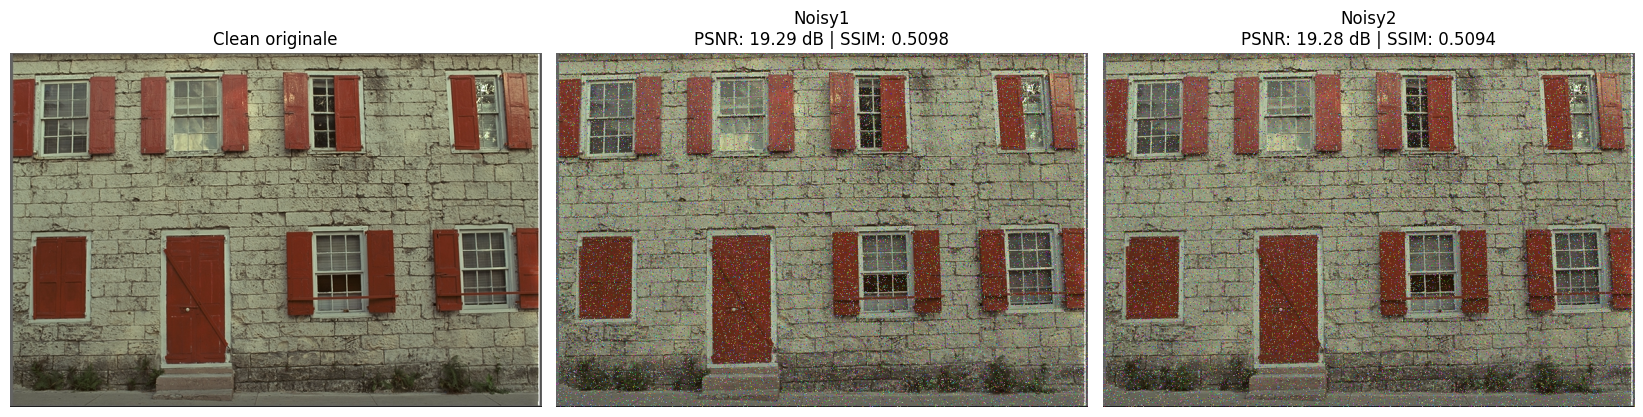

PSNR clean/noisy1: 19.29341456273948
PSNR clean/noisy2: 19.280500276406137
SSIM clean/noisy1: 0.5098081
SSIM clean/noisy2: 0.5094495


In [13]:
show_n2n_noisy_pair(
    clean_dir=kodak_clean_dir,
    noisy1_dir=kodak_noisy1_dir,
    noisy2_dir=kodak_noisy2_dir,
    index=0
)

## Logica del dataset Noise2Noise: noisy1, noisy2, validation e test set

Nel paradigma **Noise2Noise**, la rete non viene addestrata utilizzando immagini pulite come target.  
L'idea fondamentale è generare, a partire dalla stessa immagine originale, due versioni rumorose indipendenti:

```text
clean image → noisy1
clean image → noisy2
```
Le due immagini **noisy1** e **noisy2** rappresentano lo stesso contenuto visivo, ma contengono due realizzazioni diverse del rumore.
Formalmente, si può scrivere:

noisy1 = clean + n1
noisy2 = clean + n2

Durante il training, la rete riceve in input una patch estratta da noisy1 e deve predire la patch corrispondente estratta da noisy2:

input  = patch noisy1
target = patch noisy2

La rete non vede mai l'immagine pulita durante l'addestramento.

In [14]:
# -----------------------------
# BSD500 noisy1/noisy2 split
# -----------------------------

bsd500_train_noisy1_dir = bsd500_noisy1_dir / "train"
bsd500_val_noisy1_dir   = bsd500_noisy1_dir / "val"
bsd500_test_noisy1_dir  = bsd500_noisy1_dir / "test"

bsd500_train_noisy2_dir = bsd500_noisy2_dir / "train"
bsd500_val_noisy2_dir   = bsd500_noisy2_dir / "val"
bsd500_test_noisy2_dir  = bsd500_noisy2_dir / "test"


# -----------------------------
# DIV2K noisy1/noisy2 split
# -----------------------------

div2k_train_noisy1_dir = div2k_noisy1_base_dir / "DIV2K_train_HR"
div2k_valid_noisy1_dir = div2k_noisy1_base_dir / "DIV2K_valid_HR"

div2k_train_noisy2_dir = div2k_noisy2_base_dir / "DIV2K_train_HR"
div2k_valid_noisy2_dir = div2k_noisy2_base_dir / "DIV2K_valid_HR"

In [15]:
bsd500_train_noisy1_paths = get_image_paths(bsd500_train_noisy1_dir)
bsd500_val_noisy1_paths   = get_image_paths(bsd500_val_noisy1_dir)

div2k_train_noisy1_paths = get_image_paths(div2k_train_noisy1_dir)[:200]
div2k_val_noisy1_paths   = get_image_paths(div2k_valid_noisy1_dir)[:20]

train_noisy1_paths = bsd500_train_noisy1_paths + div2k_train_noisy1_paths
val_noisy1_paths   = bsd500_val_noisy1_paths + div2k_val_noisy1_paths

print("Training images:", len(train_noisy1_paths))
print("Validation images:", len(val_noisy1_paths))

Training images: 400
Validation images: 120


In [16]:
def get_corresponding_noisy2_path(noisy1_path, noisy1_root, noisy2_root):
    """
    Dato il path di una immagine noisy1, restituisce il path corrispondente
    della stessa immagine nella cartella noisy2.
    """

    noisy1_path = Path(noisy1_path)
    noisy1_root = Path(noisy1_root)
    noisy2_root = Path(noisy2_root)

    relative_path = noisy1_path.relative_to(noisy1_root)

    return noisy2_root / relative_path

In [17]:
def extract_paired_random_patches(
    noisy1_paths,
    noisy1_roots,
    noisy2_roots,
    patch_size=64,
    patches_per_image=10,
    seed=42
):
    """
    Estrae coppie di patch corrispondenti da noisy1 e noisy2.

    X = patch presa da noisy1
    Y = patch corrispondente presa da noisy2

    Queste coppie vengono usate per addestrare Noise2Noise:
        input  = X
        target = Y
    """

    rng = np.random.default_rng(seed)

    X_patches = []
    Y_patches = []

    for noisy1_path in tqdm(noisy1_paths):

        noisy1_path = Path(noisy1_path)

        matched_root = None
        matched_target_root = None

        # Capisce se l'immagine appartiene a BSD500 o DIV2K
        for root1, root2 in zip(noisy1_roots, noisy2_roots):
            try:
                noisy1_path.relative_to(root1)
                matched_root = Path(root1)
                matched_target_root = Path(root2)
                break
            except ValueError:
                continue

        if matched_root is None:
            print("Root non trovata per:", noisy1_path)
            continue

        noisy2_path = get_corresponding_noisy2_path(
            noisy1_path,
            matched_root,
            matched_target_root
        )

        if not noisy2_path.exists():
            print("Noisy2 non trovata:", noisy2_path)
            continue

        img1 = Image.open(noisy1_path).convert("RGB")
        img2 = Image.open(noisy2_path).convert("RGB")

        img1 = np.array(img1).astype(np.float32) / 255.0
        img2 = np.array(img2).astype(np.float32) / 255.0

        h, w, c = img1.shape

        if h < patch_size or w < patch_size:
            print("Immagine troppo piccola, saltata:", noisy1_path)
            continue

        for _ in range(patches_per_image):
            y = rng.integers(0, h - patch_size + 1)
            x = rng.integers(0, w - patch_size + 1)

            patch1 = img1[y:y + patch_size, x:x + patch_size, :]
            patch2 = img2[y:y + patch_size, x:x + patch_size, :]

            X_patches.append(patch1)
            Y_patches.append(patch2)

    X_patches = np.array(X_patches, dtype=np.float16)
    Y_patches = np.array(Y_patches, dtype=np.float16)

    print("X patches:", X_patches.shape)
    print("Y patches:", Y_patches.shape)

    return X_patches, Y_patches

In [18]:
X_train, Y_train = extract_paired_random_patches(
    noisy1_paths=train_noisy1_paths,
    noisy1_roots=[
        bsd500_train_noisy1_dir,
        div2k_train_noisy1_dir
    ],
    noisy2_roots=[
        bsd500_train_noisy2_dir,
        div2k_train_noisy2_dir
    ],
    patch_size=64,
    patches_per_image=5,
    seed=42
)

X_val, Y_val = extract_paired_random_patches(
    noisy1_paths=val_noisy1_paths,
    noisy1_roots=[
        bsd500_val_noisy1_dir,
        div2k_valid_noisy1_dir
    ],
    noisy2_roots=[
        bsd500_val_noisy2_dir,
        div2k_valid_noisy2_dir
    ],
    patch_size=64,
    patches_per_image=2,
    seed=123
)

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

100%|██████████| 400/400 [00:55<00:00,  7.21it/s]


X patches: (2000, 64, 64, 3)
Y patches: (2000, 64, 64, 3)


100%|██████████| 120/120 [00:04<00:00, 24.90it/s]

X patches: (240, 64, 64, 3)
Y patches: (240, 64, 64, 3)
X_train: (2000, 64, 64, 3)
Y_train: (2000, 64, 64, 3)
X_val: (240, 64, 64, 3)
Y_val: (240, 64, 64, 3)


In [19]:
X_train = X_train.astype(np.float32)
Y_train = Y_train.astype(np.float32)
X_val = X_val.astype(np.float32)
Y_val = Y_val.astype(np.float32)

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models

def conv_block(x, filters):
    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)

    x = layers.Conv2D(
        filters,
        kernel_size=3,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)

    return x


def build_n2n_unet(input_shape=(64, 64, 3), base_filters=32):
    inputs = layers.Input(shape=input_shape)

    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = conv_block(p1, base_filters * 2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = conv_block(p2, base_filters * 4)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    bottleneck = conv_block(p3, base_filters * 8)

    u3 = layers.UpSampling2D((2, 2))(bottleneck)
    u3 = layers.Concatenate()([u3, c3])
    c4 = conv_block(u3, base_filters * 4)

    u2 = layers.UpSampling2D((2, 2))(c4)
    u2 = layers.Concatenate()([u2, c2])
    c5 = conv_block(u2, base_filters * 2)

    u1 = layers.UpSampling2D((2, 2))(c5)
    u1 = layers.Concatenate()([u1, c1])
    c6 = conv_block(u1, base_filters)

    outputs = layers.Conv2D(
        3,
        kernel_size=1,
        padding="same",
        activation="sigmoid"
    )(c6)

    model = models.Model(inputs, outputs)

    return model

In [21]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/n2n_saltpepper_amount005_mae_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

In [22]:
tf.keras.backend.clear_session()

model = build_n2n_unet(
    input_shape=(64, 64, 3),
    base_filters=32
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-5,
        beta_1=0.9,
        beta_2=0.99,
        epsilon=1e-8
    ),
    loss="mae",
    metrics=["mse"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="/kaggle/working/n2n_random_impulse_p010_mae_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_val, Y_val),
    epochs=40,
    batch_size=4,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)

I0000 00:00:1780847842.785555      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780847842.794011      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/40


I0000 00:00:1780847849.139880      75 service.cc:152] XLA service 0x7ed18001e840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780847849.139918      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780847849.139921      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780847850.027126      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-07 15:57:32.268702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 15:57:32.410974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 13/500 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2407 - mse: 0.0816

I0000 00:00:1780847856.607898      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1578 - mse: 0.0430
Epoch 1: val_loss improved from inf to 0.10674, saving model to /kaggle/working/n2n_random_impulse_p010_mae_best.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - loss: 0.1576 - mse: 0.0429 - val_loss: 0.1067 - val_mse: 0.0220 - learning_rate: 5.0000e-05
Epoch 2/40
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1031 - mse: 0.0233
Epoch 2: val_loss improved from 0.10674 to 0.08705, saving model to /kaggle/working/n2n_random_impulse_p010_mae_best.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1031 - mse: 0.0233 - val_loss: 0.0870 - val_mse: 0.0175 - learning_rate: 5.0000e-05
Epoch 3/40
494/500 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0864 - mse: 0.0193
Epoch 3: val_loss improved from 0.08705 to 0.07470, saving model to /kaggle/working/n2n_random_impulse_p010_mae_best.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0864 - mse: 0.0193 - val_loss: 0.0747 - val_mse: 0.0151 - learning_rate: 5.0000e

In [23]:
def pad_to_multiple_of_8(img):
    """
    Aggiunge padding riflesso a un'immagine affinché altezza e larghezza
    siano divisibili per 8.

    Questo è necessario perché la U-Net usa 3 livelli di MaxPooling,
    quindi le dimensioni devono essere compatibili con 2^3 = 8.
    """

    h, w, c = img.shape

    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8

    padded = np.pad(
        img,
        ((0, pad_h), (0, pad_w), (0, 0)),
        mode="reflect"
    )

    return padded, h, w

In [24]:
def denoise_dataset_with_n2n(
    model,
    noisy_dir,
    clean_dir,
    output_dir,
    csv_name="metrics.csv"
):
    """
    Applica il modello Noise2Noise a tutte le immagini rumorose di noisy_dir,
    salva le immagini denoised in output_dir e calcola PSNR/SSIM rispetto
    alle immagini clean corrispondenti.

    Il modello riceve in input una immagine noisy1 e produce una versione denoised.
    Le immagini clean vengono usate solo per la valutazione finale.
    """

    noisy_dir = Path(noisy_dir)
    clean_dir = Path(clean_dir)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    noisy_paths = get_image_paths(noisy_dir)

    results = []

    for noisy_path in tqdm(noisy_paths):
        try:
            relative_path = noisy_path.relative_to(noisy_dir)
            clean_path = clean_dir / relative_path

            if not clean_path.exists():
                print("Clean non trovata:", clean_path)
                continue

            # Lettura immagine rumorosa
            noisy_img = Image.open(noisy_path).convert("RGB")
            noisy_np = np.array(noisy_img).astype(np.float32) / 255.0

            # Predizione N2N
            noisy_padded, original_h, original_w = pad_to_multiple_of_8(noisy_np)

            input_tensor = np.expand_dims(noisy_padded, axis=0)

            pred_padded = model.predict(input_tensor, verbose=0)[0]

            pred = pred_padded[:original_h, :original_w, :]
            pred = np.clip(pred, 0, 1)

            # Salvataggio immagine denoised
            save_path = output_dir / relative_path
            save_path = save_path.with_suffix(".png")
            save_path.parent.mkdir(parents=True, exist_ok=True)

            Image.fromarray((pred * 255).astype(np.uint8)).save(save_path)

            # Lettura clean
            clean_img = Image.open(clean_path).convert("RGB")
            clean_img = clean_img.resize((noisy_np.shape[1], noisy_np.shape[0]))
            clean_np = np.array(clean_img).astype(np.float32) / 255.0

            # Metriche noisy
            psnr_noisy = psnr(clean_np, noisy_np, data_range=1.0)
            ssim_noisy = ssim(clean_np, noisy_np, channel_axis=2, data_range=1.0)

            # Metriche N2N
            psnr_n2n = psnr(clean_np, pred, data_range=1.0)
            ssim_n2n = ssim(clean_np, pred, channel_axis=2, data_range=1.0)

            results.append({
                "filename": str(relative_path),
                "clean_path": str(clean_path),
                "noisy_path": str(noisy_path),
                "denoised_path": str(save_path),
                "psnr_clean_noisy": float(psnr_noisy),
                "ssim_clean_noisy": float(ssim_noisy),
                "psnr_clean_n2n": float(psnr_n2n),
                "ssim_clean_n2n": float(ssim_n2n),
                "psnr_gain": float(psnr_n2n - psnr_noisy),
                "ssim_gain": float(ssim_n2n - ssim_noisy),
            })

        except Exception as e:
            print("Errore su:", noisy_path)
            print(e)

    df = pd.DataFrame(results)

    csv_path = output_dir / csv_name
    df.to_csv(csv_path, index=False)

    print("CSV salvato in:", csv_path)

    if len(df) > 0:
        print("PSNR medio clean/noisy:", df["psnr_clean_noisy"].mean())
        print("PSNR medio clean/N2N:", df["psnr_clean_n2n"].mean())
        print("Gain PSNR medio:", df["psnr_gain"].mean())

        print("SSIM medio clean/noisy:", df["ssim_clean_noisy"].mean())
        print("SSIM medio clean/N2N:", df["ssim_clean_n2n"].mean())
        print("Gain SSIM medio:", df["ssim_gain"].mean())

    return df

In [25]:
model_flexible = build_n2n_unet(
    input_shape=(None, None, 3),
    base_filters=32
)

model_flexible.set_weights(model.get_weights())

In [26]:
df_kodak_n2n = denoise_dataset_with_n2n(
    model=model_flexible,
    noisy_dir=kodak_noisy1_dir,
    clean_dir=kodak_clean_dir,
    output_dir=n2n_output_dir / "kodak",
    csv_name="kodak_random_impulse_p010_n2n_metrics.csv"
)

  0%|          | 0/24 [00:00<?, ?it/s]2026-06-07 16:00:41.850424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:00:42.053197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:00:42.626083: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:00:42.888715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
 12%|█▎        | 3/24 

CSV salvato in: /kaggle/working/n2n_random_impulse_p010_outputs/kodak/kodak_random_impulse_p010_n2n_metrics.csv
PSNR medio clean/noisy: 18.562859204948357
PSNR medio clean/N2N: 28.652155233478652
Gain PSNR medio: 10.089296028530292
SSIM medio clean/noisy: 0.34159004253645736
SSIM medio clean/N2N: 0.8073924978574117
Gain SSIM medio: 0.4658024547000726


In [27]:
df_bsd500_n2n = denoise_dataset_with_n2n(
    model=model_flexible,
    noisy_dir=bsd500_test_noisy1_dir,
    clean_dir=bsd500_test_clean_dir,
    output_dir=n2n_output_dir / "bsd500_test",
    csv_name="bsd500_test_random_impulse_p010_n2n_metrics.csv"
)

  0%|          | 0/200 [00:00<?, ?it/s]2026-06-07 16:01:03.884449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:01:04.115089: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
  2%|▎         | 5/200 [00:04<01:38,  1.98it/s]2026-06-07 16:01:08.089752: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:01:08.322634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please inves

CSV salvato in: /kaggle/working/n2n_random_impulse_p010_outputs/bsd500_test/bsd500_test_random_impulse_p010_n2n_metrics.csv
PSNR medio clean/noisy: 19.941086790666613
PSNR medio clean/N2N: 27.905143148071744
Gain PSNR medio: 7.964056357405132
SSIM medio clean/noisy: 0.44543897844851016
SSIM medio clean/N2N: 0.8207348230481147
Gain SSIM medio: 0.3752958451211452


In [28]:
df_div2k_n2n = denoise_dataset_with_n2n(
    model=model_flexible,
    noisy_dir=div2k_valid_noisy1_dir,
    clean_dir=div2k_valid_clean_dir,
    output_dir=n2n_output_dir / "div2k_valid",
    csv_name="div2k_valid_random_impulse_p010_n2n_metrics.csv"
)

  0%|          | 0/100 [00:00<?, ?it/s]2026-06-07 16:01:57.860670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:01:58.018077: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:01:59.256836: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:01:59.480691: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 16:02:00.4

CSV salvato in: /kaggle/working/n2n_random_impulse_p010_outputs/div2k_valid/div2k_valid_random_impulse_p010_n2n_metrics.csv
PSNR medio clean/noisy: 17.76351569493889
PSNR medio clean/N2N: 29.090742279824703
Gain PSNR medio: 11.327226584885816
SSIM medio clean/noisy: 0.31902711421251295
SSIM medio clean/N2N: 0.8276843798160552
Gain SSIM medio: 0.5086572659015656
